# Life expectancy through history

Life expectancy at birth, computed as `deathdate − birthdate` in years, for every individual in the database with **both** a `birthdate` and a `deathdate` known to **at least year precision** (Wikidata `precision >= 9` — year, month, or day). Lower-precision dates (decade, century, millennium) are excluded so that birth- and death-year are unambiguous. Analysis is restricted to **birth year ≤ 1900** to avoid right-truncation by people still alive.

- **Faint dots**: each individual at their **actual birth year**.
- **Coloured dots**: the **median life expectancy** within each 50-year birth bin (only bins with **≥ 50 individuals** are plotted).
- **Solid line**: the medians connected directly.

X-axis is in centuries, starting at 800 BC.

In [1]:
import duckdb
from pathlib import Path

import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

DB_PATH = Path('..') / 'data' / 'humans_clean.duckdb'

FIGSIZE = (11, 4.5)
DPI = 130
COLOR_DOT = '#9aa0a6'
COLOR_LINE = '#c1121f'
COLOR_AXIS = '#444444'

mpl.rcParams.update({
    'figure.figsize': FIGSIZE,
    'figure.dpi': DPI,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


## Load

We load only the rows where `birthdate` and `deathdate` are real dates known to **at least year precision** (Wikidata `precision >= 9`: year, month, or day) and not Wikidata blank-nodes. This excludes decade-, century-, and millennium-precision dates, where the year itself is uncertain. Life expectancy is computed inline as `deathdate − birthdate` in fractional years, using a regex parser that handles BC dates of the form `-YYYY-MM-DD`. We keep only finite values in `[0, 130]`.

In [2]:
def parse_year_frac(date_col: str) -> pl.Expr:
    """Wikidata ISO date -> fractional year. Handles '-YYYY-MM-DD' (BC).
    Missing month/day default to 1. Unparsable strings yield null."""
    s = pl.col(date_col)
    is_bc = s.str.starts_with('-')
    year = s.str.extract(r'^-?(\d{1,5})', 1).cast(pl.Int64, strict=False)
    month = s.str.extract(r'^-?\d{1,5}-(\d{1,2})', 1).cast(pl.Int64, strict=False).fill_null(1)
    day = s.str.extract(r'^-?\d{1,5}-\d{1,2}-(\d{1,2})', 1).cast(pl.Int64, strict=False).fill_null(1)
    signed_year = pl.when(is_bc).then(-year).otherwise(year)
    return (signed_year + (30 * (month - 1) + (day - 1)) / 365.0).alias(f'{date_col}_yr')


conn = duckdb.connect(DB_PATH, read_only=True)
raw = conn.execute("""
    SELECT wikidata_id, birthdate, deathdate
    FROM individuals
    WHERE birthdate IS NOT NULL
      AND deathdate IS NOT NULL
      AND birthdate NOT LIKE '\\_:%' ESCAPE '\\'
      AND deathdate NOT LIKE '\\_:%' ESCAPE '\\'
      AND birthdate_precision >= 9
      AND deathdate_precision >= 9
    """).pl()
conn.close()
print(f'{raw.height:,} candidate rows (both dates year-precision or finer)')

df = (
    raw
    .with_columns([parse_year_frac('birthdate'), parse_year_frac('deathdate')])
    .with_columns([
        (pl.col('deathdate_yr') - pl.col('birthdate_yr')).alias('life_expectancy_years'),
        pl.col('birthdate_yr').floor().cast(pl.Int64).alias('birth_year'),
    ])
    .drop_nulls(['life_expectancy_years', 'birth_year'])
    .filter((pl.col('life_expectancy_years') >= 0) & (pl.col('life_expectancy_years') <= 130))
)
print(f'{df.height:,} individuals with valid life expectancy in [0, 130]')
df.select(['birth_year', 'life_expectancy_years']).describe()

3,117,213 candidate rows (both dates year-precision or finer)


3,116,512 individuals with valid life expectancy in [0, 130]


statistic,birth_year,life_expectancy_years
str,f64,f64
"""count""",3.116512e6,3.116512e6
"""null_count""",0.0,0.0
"""mean""",1848.042549,68.58191
"""std""",148.091808,17.867657
"""min""",-3274.0,0.0
"""25%""",1831.0,59.0
"""50%""",1889.0,71.750685
"""75%""",1920.0,81.561644
"""max""",2025.0,130.0


## Aggregate by 50-year birth bin

Floor each birth year to its 50-year bin (`bin = birth_year // 50 * 50`) and compute the **median** life expectancy per bin. Bins with **fewer than 50 individuals** are dropped. Restrict to bins ending at or before 1900.

In [3]:
BIN_WIDTH = 50
MIN_BIN_N = 50            # require at least 50 year-precision individuals per bin
MAX_BIRTH_YEAR = 1900     # right-truncation cutoff

binned = (
    df
    .filter(pl.col('birth_year') <= MAX_BIRTH_YEAR)
    .with_columns((pl.col('birth_year') // BIN_WIDTH * BIN_WIDTH).cast(pl.Int64).alias('bin'))
    .group_by('bin')
    .agg(
        pl.col('life_expectancy_years').median().alias('median_life_expectancy'),
        pl.col('life_expectancy_years').mean().alias('mean_life_expectancy'),
        pl.len().alias('n'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('bin')
)
print(f'{binned.height} 50-year bins with n >= {MIN_BIN_N}, '
      f'range {binned["bin"].min()} ... {binned["bin"].max()}')
binned.head(8)

49 50-year bins with n >= 50, range -500 ... 1900


bin,median_life_expectancy,mean_life_expectancy,n
i64,f64,f64,u32
-500,66.0,64.449129,59
-450,57.0,60.019569,63
-400,60.0,60.593073,106
-350,60.0,57.769806,96
-300,56.0,55.836323,93
-250,51.5,51.907159,106
-200,57.0,54.484342,93
-150,56.0,56.710928,131


## Plot — every individual + binned median + connecting line

Each individual is plotted at its **real birth year**. Coloured dots are the median life expectancy in each 50-year bin (only bins with **≥ 50 individuals** are shown). The solid line connects the medians directly (no smoothing).

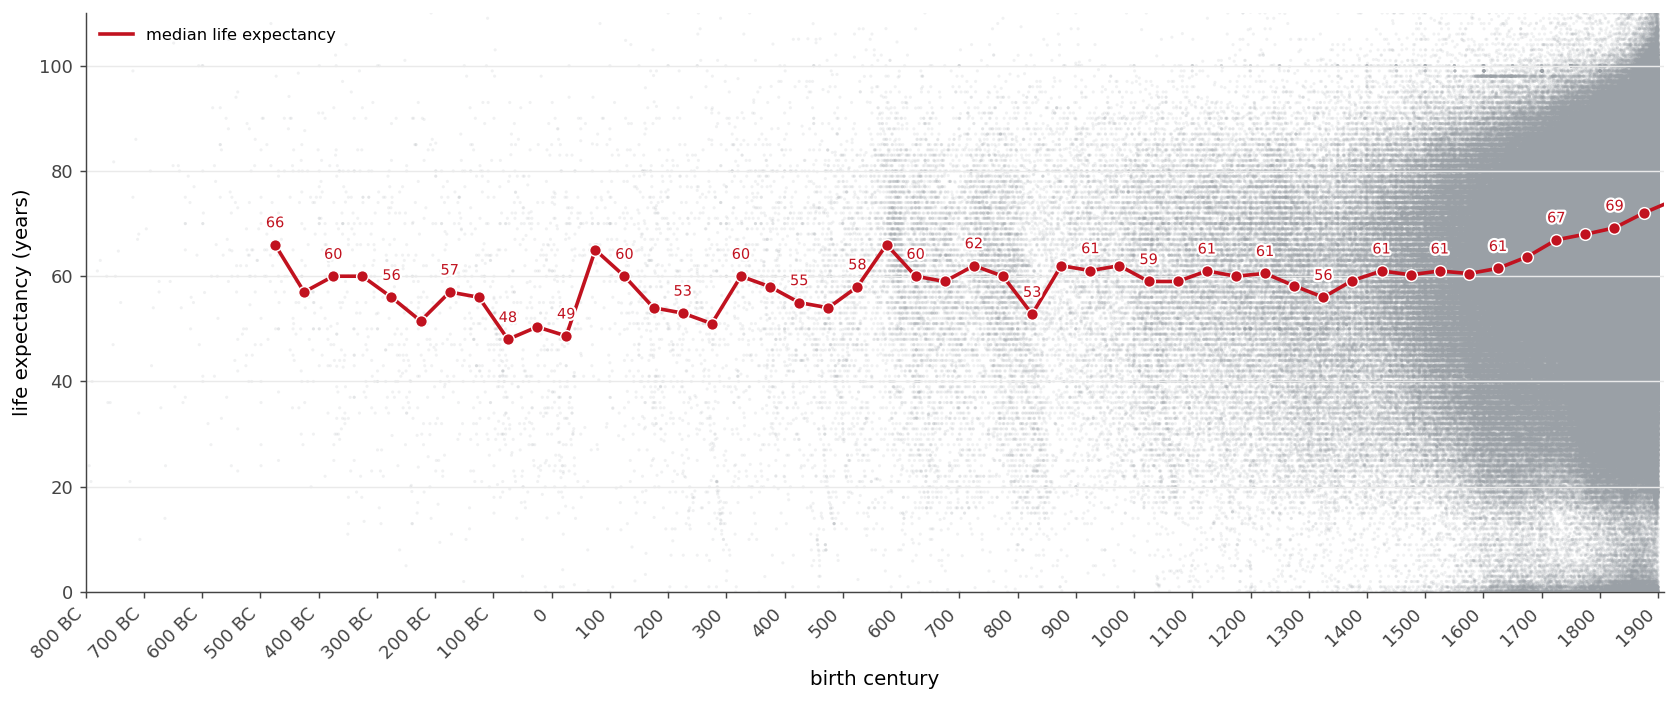

In [4]:
X_MIN, X_MAX = -800, 1910

# Each individual at its real birth year (no jitter, no snapping).
ind = df.filter((pl.col('birth_year') >= X_MIN) & (pl.col('birth_year') <= MAX_BIRTH_YEAR))
ind_x = ind['birth_year'].to_numpy()
ind_y = ind['life_expectancy_years'].to_numpy()

# Bin medians (already filtered to n >= MIN_BIN_N upstream)
plot_bins = binned.filter(pl.col('bin') >= X_MIN).sort('bin')
bin_x = plot_bins['bin'].to_numpy() + BIN_WIDTH / 2
bin_med = plot_bins['median_life_expectancy'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 5.5))

# Background swarm: every individual at real birth year (no legend entry)
ax.scatter(ind_x, ind_y, s=3.0, color='#9aa0a6', alpha=0.14, edgecolor='none',
           rasterized=True, zorder=1)

# Direct line through the 50-year medians + dots on top
ax.plot(bin_x, bin_med, color=COLOR_LINE, lw=2.0, zorder=4,
        label='median life expectancy')
ax.scatter(bin_x, bin_med, s=42, color=COLOR_LINE, edgecolor='white', lw=0.8, zorder=5)

# Small age label every 2 bins (every 100 yr) above the median dot.
# White halo (path effects) keeps the number readable against the gray scatter cloud.
for i, (x, y) in enumerate(zip(bin_x, bin_med)):
    if i % 2 == 0:
        ax.annotate(f'{y:.0f}', (x, y),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', va='bottom',
                    fontsize=8, color=COLOR_LINE, zorder=6,
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

century_ticks = np.arange(-800, 1901, 100)
labels = [f'{abs(c)} BC' if c < 0 else ('0' if c == 0 else f'{c}') for c in century_ticks]
ax.set_xticks(century_ticks)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, 110)

ax.set_ylabel('life expectancy (years)')
ax.set_xlabel('birth century')
ax.grid(axis='y', color='#eaeaea', lw=0.8)
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.tick_params(axis='both', colors=COLOR_AXIS)
for spine in ax.spines.values():
    spine.set_color(COLOR_AXIS)

plt.tight_layout()
plt.show()


## Caveats

- This is **recorded** life expectancy at birth among individuals notable enough to appear in Wikidata, **not** population life expectancy in the demographic sense. Wikidata heavily over-represents people who lived long enough to acquire a public record — children and infants are essentially absent. The trend is the median life expectancy *of recorded individuals*, not of the underlying population.
- The 1900 cutoff removes individuals still alive (right-truncation): if we kept post-1900 cohorts, their medians would collapse simply because the long-lived members of those cohorts have not died yet.
- The `n ≥ 50` per-bin threshold prevents medians from being driven by a handful of outliers in sparsely-recorded ancient bins, so empty regions of the plot reflect *insufficient year-precision data*, not missing lives.

## Life expectancy by cross-verified occupational category

We restrict to individuals also present in the **cross-verified database** (Laouenan et al., 2022) and use its top-level occupational taxonomy `level1_main_occ` (six categories: *Culture*, *Discovery/Science*, *Leadership*, *Sports/Games*, *Other*, *Missing*). Each individual is plotted at its real birth year, coloured by category. For each category we compute the median life expectancy per 50-year birth bin (only bins with **≥ 50 individuals in that category** are plotted) and connect those medians directly with a line — no smoothing.

CV provides `wikidata_code`, which we join to our `wikidata_id`. Categories `Missing` and `Other` are dropped from the plot for legibility.

In [5]:
CV_PATH = Path('..') / 'data' / 'similar_databases' / 'cross-verified-database' / 'cross-verified-database.utf8.csv.gz'

cv = pl.read_csv(
    CV_PATH,
    columns=['wikidata_code', 'level1_main_occ'],
    schema_overrides={'wikidata_code': pl.Utf8, 'level1_main_occ': pl.Utf8},
)
cv = cv.drop_nulls(['wikidata_code', 'level1_main_occ']).rename({'wikidata_code': 'wikidata_id'})
print(f'CV rows with wikidata_code + level1: {cv.height:,}')
print(cv['level1_main_occ'].value_counts().sort('count', descending=True))

CV rows with wikidata_code + level1: 2,291,817
shape: (6, 2)
┌───────────────────┬────────┐
│ level1_main_occ   ┆ count  │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ Culture           ┆ 702330 │
│ Sports/Games      ┆ 633450 │
│ Leadership        ┆ 619146 │
│ Discovery/Science ┆ 273229 │
│ Other             ┆ 48245  │
│ Missing           ┆ 15417  │
└───────────────────┴────────┘


In [6]:
df_cv = (
    df.join(cv, on='wikidata_id', how='inner')
      .filter(pl.col('birth_year') <= MAX_BIRTH_YEAR)
)
print(f'{df_cv.height:,} CV-matched individuals with valid life expectancy (≤ 1900)')

binned_cat = (
    df_cv
    .with_columns((pl.col('birth_year') // BIN_WIDTH * BIN_WIDTH).cast(pl.Int64).alias('bin'))
    .group_by(['level1_main_occ', 'bin'])
    .agg(
        pl.col('life_expectancy_years').median().alias('median_life_expectancy'),
        pl.len().alias('n'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort(['level1_main_occ', 'bin'])
)
binned_cat.group_by('level1_main_occ').agg(
    pl.col('n').sum().alias('total_n_in_kept_bins'),
    pl.len().alias('n_bins_kept'),
).sort('total_n_in_kept_bins', descending=True)

585,303 CV-matched individuals with valid life expectancy (≤ 1900)


level1_main_occ,total_n_in_kept_bins,n_bins_kept
str,u32,u32
"""Leadership""",262937,44
"""Culture""",155022,23
"""Discovery/Science""",95523,22
"""Sports/Games""",42661,5
"""Other""",20761,18
"""Missing""",6178,11


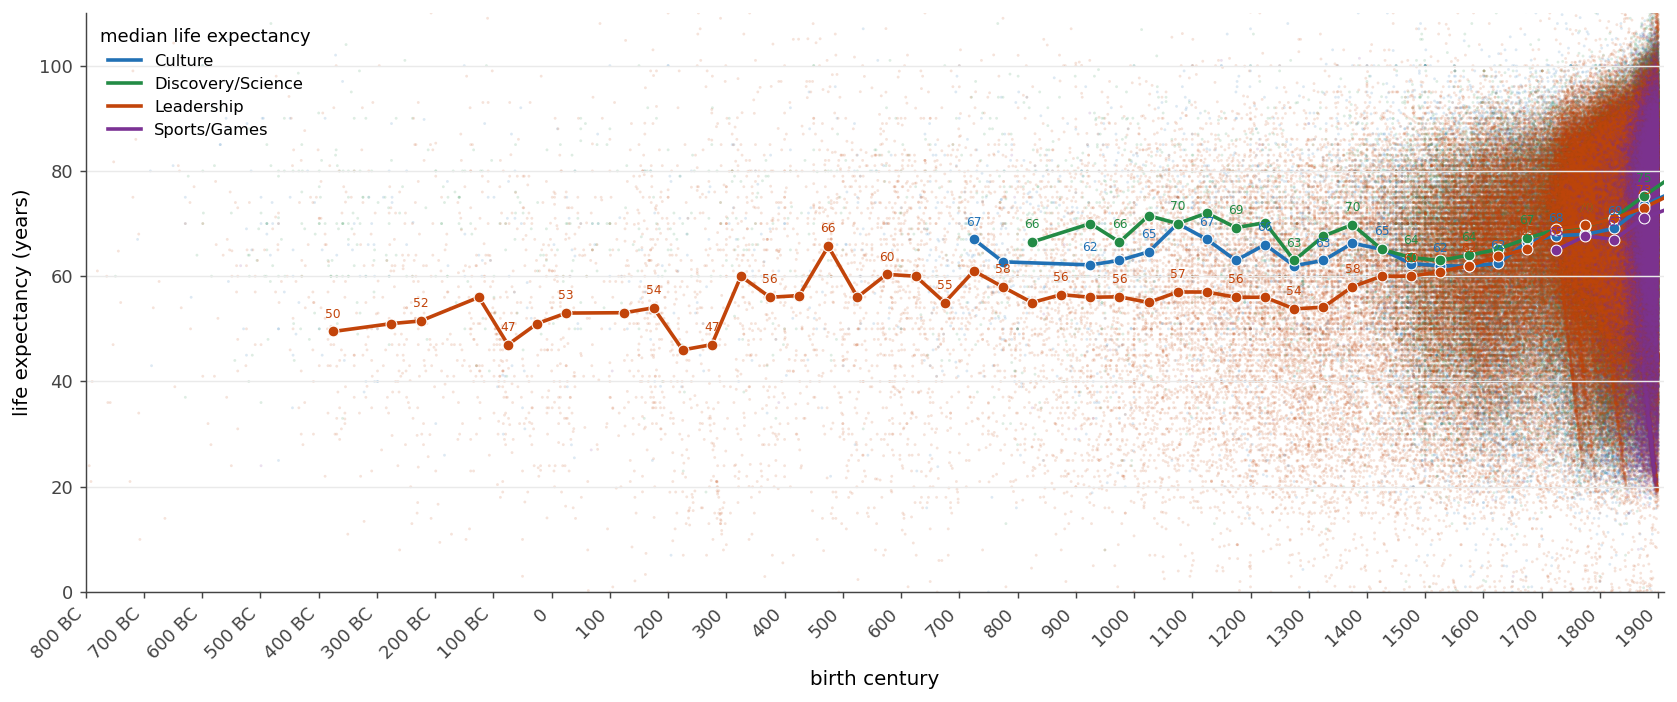

In [7]:
CAT_COLORS = {
    'Culture':           '#2171b5',
    'Discovery/Science': '#238b45',
    'Leadership':        '#c2440a',
    'Sports/Games':      '#7b3294',
}
SHOW_CATS = list(CAT_COLORS.keys())

fig, ax = plt.subplots(figsize=(13, 5.5))

# Background: every CV-matched individual at its real birth year, coloured by category (no legend entries)
for cat in SHOW_CATS:
    pts = df_cv.filter(
        (pl.col('level1_main_occ') == cat)
        & (pl.col('birth_year') >= X_MIN)
    )
    if pts.height == 0:
        continue
    ax.scatter(
        pts['birth_year'].to_numpy(),
        pts['life_expectancy_years'].to_numpy(),
        s=2.5,
        color=CAT_COLORS[cat],
        alpha=0.15,
        edgecolor='none',
        rasterized=True,
        zorder=1,
    )

# Foreground: median per 50-year bin, connected directly per category, with age labels every 2 bins
for cat in SHOW_CATS:
    sub = (
        binned_cat
        .filter((pl.col('level1_main_occ') == cat) & (pl.col('bin') >= X_MIN))
        .sort('bin')
    )
    if sub.height == 0:
        continue
    bx = sub['bin'].to_numpy() + BIN_WIDTH / 2
    bm = sub['median_life_expectancy'].to_numpy()
    color = CAT_COLORS[cat]
    ax.plot(bx, bm, color=color, lw=2.0, label=cat, zorder=4)
    ax.scatter(bx, bm, s=36, color=color, edgecolor='white', lw=0.6, zorder=5)
    for i, (x, y) in enumerate(zip(bx, bm)):
        if i % 2 == 0:
            ax.annotate(f'{y:.0f}', (x, y),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', va='bottom',
                        fontsize=6.8, color=color, zorder=6)

ax.set_xticks(century_ticks)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(0, 110)

ax.set_ylabel('life expectancy (years)')
ax.set_xlabel('birth century')
ax.grid(axis='y', color='#eaeaea', lw=0.8)
ax.legend(frameon=False, loc='upper left', fontsize=9, ncol=1, title='median life expectancy')
ax.tick_params(axis='both', colors=COLOR_AXIS)
for spine in ax.spines.values():
    spine.set_color(COLOR_AXIS)

plt.tight_layout()
plt.show()

## Export 50-yr birth-bin medians for the estimator

Save both lookup tables — overall (`category=`) and per CV `level1_main_occ` — to one CSV, so `scripts/_one_off/estimate_dates_v2.py` can consume the **same** numbers that this graph plots. No need to recompute them inside the script (which risks drift).

In [8]:
OUT_LOOKUP_CSV = Path('..') / 'data' / 'life_expectancy_medians_50yr.csv'

overall = (
    binned
    .select(
        pl.lit('').alias('category'),
        pl.col('bin').alias('birth_bin'),
        pl.col('median_life_expectancy').alias('median_life_expectancy'),
        pl.col('mean_life_expectancy').alias('mean_life_expectancy'),
        pl.col('n').alias('n'),
    )
)

per_cat = (
    binned_cat
    .select(
        pl.col('level1_main_occ').alias('category'),
        pl.col('bin').alias('birth_bin'),
        pl.col('median_life_expectancy').alias('median_life_expectancy'),
        pl.lit(None, dtype=pl.Float64).alias('mean_life_expectancy'),
        pl.col('n').alias('n'),
    )
)

lookups_out = pl.concat([overall, per_cat]).sort(['category', 'birth_bin'])
lookups_out.write_csv(OUT_LOOKUP_CSV)
print(f'Wrote {lookups_out.height} rows -> {OUT_LOOKUP_CSV}')
print(f'  overall bins: {overall.height}')
print(f'  per-category bins: {per_cat.height}')
lookups_out.head(10)

Wrote 172 rows -> ../data/life_expectancy_medians_50yr.csv
  overall bins: 49
  per-category bins: 123


category,birth_bin,median_life_expectancy,mean_life_expectancy,n
str,i64,f64,f64,u32
"""""",-500,66.0,64.449129,59
"""""",-450,57.0,60.019569,63
"""""",-400,60.0,60.593073,106
"""""",-350,60.0,57.769806,96
"""""",-300,56.0,55.836323,93
"""""",-250,51.5,51.907159,106
"""""",-200,57.0,54.484342,93
"""""",-150,56.0,56.710928,131
"""""",-100,48.0,49.566819,171


## Sanity check — 100 estimated-date annotations

Inspect a stratified sample of individuals whose missing birth- or death-date was filled by the Rust pipeline (`scripts/database_integration_scripts_V2/21_estimate_dates_from_life_expectancy`). For each row we show name, CV occupational category, the original known date, the estimated counterpart, and the implied life expectancy used.

Sampling: 25 rows per major CV category (`Culture`, `Discovery/Science`, `Leadership`, `Sports/Games`), shuffled deterministically (seed = 0).

In [9]:
import random

conn = duckdb.connect(DB_PATH, read_only=True)
sample_raw = conn.execute("""
    SELECT wikidata_id, name_en, birthdate, deathdate,
           birthdate_from_life_expectancy AS est_birth,
           deathdate_from_life_expectancy AS est_death
    FROM individuals
    WHERE birthdate_from_life_expectancy IS NOT NULL
       OR deathdate_from_life_expectancy IS NOT NULL
    """).pl()
conn.close()
print(f'{sample_raw.height:,} individuals with at least one estimated date')

sample = (
    sample_raw
    .join(cv, on='wikidata_id', how='left')
    .with_columns(pl.col('level1_main_occ').fill_null('(no CV category)').alias('category'))
)

CATS = ['Culture', 'Discovery/Science', 'Leadership', 'Sports/Games']
PER_CAT = 25
SEED = 0

parts = []
for cat in CATS:
    sub = sample.filter(pl.col('category') == cat)
    n = min(PER_CAT, sub.height)
    parts.append(sub.sample(n=n, seed=SEED))
ann = pl.concat(parts).sample(fraction=1.0, seed=SEED)  # shuffle

def _yr(s: str | None) -> int | None:
    if s is None:
        return None
    s = s.strip()
    sign = -1 if s.startswith('-') else 1
    body = s[1:] if sign == -1 else s
    try:
        return sign * int(body[:4])
    except ValueError:
        return None

rows = []
for r in ann.iter_rows(named=True):
    by = _yr(r['birthdate'])
    dy = _yr(r['deathdate'])
    eby = _yr(r['est_birth'])
    edy = _yr(r['est_death'])
    if eby is not None and dy is not None:
        kind = 'birth←'
        anchor_year = dy
        est_year = eby
        life_exp = dy - eby
    elif edy is not None and by is not None:
        kind = 'death→'
        anchor_year = by
        est_year = edy
        life_exp = edy - by
    else:
        kind = '?'
        anchor_year = by if by is not None else dy
        est_year = eby if eby is not None else edy
        life_exp = None
    rows.append({
        'wikidata_id': r['wikidata_id'],
        'name': (r['name_en'] or '')[:38],
        'category': r['category'],
        'kind': kind,
        'orig_birth': r['birthdate'][:10] if r['birthdate'] and not r['birthdate'].startswith('_:') else '',
        'orig_death': r['deathdate'][:10] if r['deathdate'] and not r['deathdate'].startswith('_:') else '',
        'est_birth': r['est_birth'][:10] if r['est_birth'] else '',
        'est_death': r['est_death'][:10] if r['est_death'] else '',
        'life_exp': life_exp,
    })

annotations = pl.DataFrame(rows)
pl.Config.set_tbl_rows(120)
pl.Config.set_tbl_width_chars(220)
annotations

1,335,507 individuals with at least one estimated date


wikidata_id,name,category,kind,orig_birth,orig_death,est_birth,est_death,life_exp
str,str,str,str,str,str,str,str,i64
"""Q2173491""","""Rudolf Müller""","""Culture""","""death→""","""1931-02-22""","""""","""""","""2007-01-01""",76
"""Q258431""","""Caroline Graham""","""Culture""","""death→""","""1931-07-17""","""""","""""","""2007-01-01""",76
"""Q24018812""","""Ragnhild Haarstad""","""Culture""","""death→""","""1935-03-30""","""""","""""","""2011-01-01""",76
"""Q10373008""","""Solano Ribeiro""","""Culture""","""death→""","""1939-01-01""","""""","""""","""2015-01-01""",76
"""Q318110""","""Randall Duk Kim""","""Culture""","""death→""","""1943-09-24""","""""","""""","""2019-01-01""",76
"""Q10858485""","""Ghadam-Ali Sarami""","""Culture""","""death→""","""1944-06-23""","""""","""""","""2020-01-01""",76
"""Q6384203""","""Keith Clifford""","""Culture""","""death→""","""1938-06-20""","""""","""""","""2014-01-01""",76
"""Q6250042""","""John Mylne""","""Culture""","""birth←""","""""","""1621-01-01""","""1559-01-01""","""""",62
"""Q2062746""","""Paul Theissen""","""Culture""","""death→""","""1937-01-01""","""""","""""","""2013-01-01""",76


In [10]:
OUT_CSV = Path('..') / 'data' / 'estimated_dates_sample_annotations.csv'
annotations.write_csv(OUT_CSV)
print(f'Saved {annotations.height} annotations -> {OUT_CSV}')

Saved 100 annotations -> ../data/estimated_dates_sample_annotations.csv
